In [ ]:
import os
import json
import numpy as np
import pandas as pd
import random
from scipy.interpolate import interp1d
import pprint
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation



In [ ]:
def list_directories(path):
    items = os.listdir(path)
    directories = [item for item in items if os.path.isdir(os.path.join(path, item))]
    
    return directories

path = 'data'
directories = list_directories(path)
print(directories)

In [ ]:
def load_json_files(data, dir_path):
    for filename in os.listdir(dir_path):
        if filename.endswith('.json'):
            filepath = os.path.join(dir_path, filename)
            with open(filepath, 'r') as file:
                json_data = json.load(file)
                data.append(json_data)
    return data


In [ ]:
def process_data(data, label):
    result = []
    for datum in data:
        datum_dict = {}
        datum_dict['label'] = label
        datum_dict['sequences'] = []      
        for sequence in datum:
            sequence_dict = {}
            sequence_dict['seq'] = int(sequence['seq'])
            sequence_dict['landmarks'] = []
            for landmark in sequence['hand_landmarks']:
                sequence_dict['landmarks'].append({
                    'id': landmark['id'],
                    'x': round(landmark['x'], 3),
                    'y': round(landmark['y'], 3),
                    'z': round(landmark.get('z', 0), 3)
                })
            sequence_dict['hand_label'] = sequence['hand_label']
            sequence_dict['label'] = label
            datum_dict['sequences'].append(sequence_dict)
        result.append(datum_dict)
    return result


In [ ]:
dataset = []
for directory in directories:
    dir_path = os.path.join(path, directory)
    data = []
    data = load_json_files(data, dir_path)
    label = directory
    processed_data = process_data(data, label)
    dataset.extend(processed_data)



In [125]:
# Convert the hand data to np array
def parse_hand_sequences(sample):
    sequences = [] 
    for seq in sample['sequences']:
        landmarks = seq['landmarks']
        sequences.append([[lm['x'], lm['y'], lm['z']] for lm in landmarks])
    return np.array(sequences)


In [124]:
# Get the labels
def parse_labels(sample):
    return sample['label']

In [ ]:
# Normalize the timeseries data to fixed length
def normalize_time_series(data, target_length):
    original_timesteps = np.arange(data.shape[0])
    new_timesteps = np.linspace(0, data.shape[0] - 1, num=target_length)
    interpolator = interp1d(original_timesteps, data, axis=0, kind='linear', fill_value="extrapolate")
    return interpolator(new_timesteps)


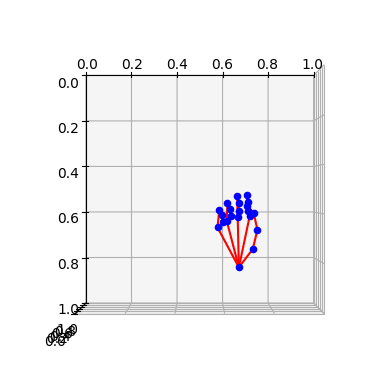

In [122]:
""" Animator for monitoring purpose """
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),  # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),  # Index finger
    (0, 9), (9, 10), (10, 11), (11, 12),  # Middle finger
    (0, 13), (13, 14), (14, 15), (15, 16),  # Ring finger
    (0, 17), (17, 18), (18, 19), (19, 20)  # Pinky
]

def update_plot(frame, data, scatters, lines):
    for i, scatter in enumerate(scatters):
        scatter.set_offsets(data[frame, i, :2])
        scatter.set_3d_properties(data[frame, i, 2], zdir='z')

    for line, (start_idx, end_idx) in zip(lines, HAND_CONNECTIONS):
        line.set_data(data[frame, [start_idx, end_idx], 0], data[frame, [start_idx, end_idx], 1])
        line.set_3d_properties(data[frame, [start_idx, end_idx], 2], zdir='z')

    return scatters + lines

def visualize_hand_landmarks(data):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    
    ax.view_init(elev=-90, azim=270)
    
    scatters = [ax.scatter(data[0, i, 0], data[0, i, 1], data[0, i, 2], c='b') for i in range(21)]
    lines = [ax.plot(data[0, [start, end], 0], data[0, [start, end], 1], data[0, [start, end], 2], c='r')[0] for start, end in HAND_CONNECTIONS]

    def animate(frame):
        update_plot(frame, data, scatters, lines)
        clear_output(wait=True)
        display(fig)
        plt.pause(0.033)  

    for frame in range(data.shape[0]):
        animate(frame)

    plt.close(fig)


In [ ]:


def format_hand_data(augmented_sequences, original_data):
    formatted_data = []
    idx = 0
    for sample in original_data:
        formatted_sample = {'label': sample['label'], 'sequences': []}
        for seq in sample['sequences']:
            formatted_seq = {'seq': seq['seq'], 'landmarks': [], 'hand_label': seq['hand_label'], 'label': seq['label']}
            for i, lm in enumerate(seq['landmarks']):
                formatted_seq['landmarks'].append({
                    'id': lm['id'],
                    'x': augmented_sequences[idx, i, 0],
                    'y': augmented_sequences[idx, i, 1],
                    'z': augmented_sequences[idx, i, 2]
                })
            formatted_sample['sequences'].append(formatted_seq)
            idx += 1
        formatted_data.append(formatted_sample)
    return formatted_data

def add_noise(data, noise_level=0.01):
    return data + noise_level * np.random.randn(*data.shape)

def scale_data(data, scale_factor=0.1):
    scaling = 1 + scale_factor * (2 * np.random.rand() - 1)
    return data * scaling

def rotate_data(data, angle_range=10):
    angle = np.deg2rad(random.uniform(-angle_range, angle_range))
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    rotated_data = np.dot(data[:, :2], rotation_matrix)
    return np.hstack((rotated_data, data[:, 2:]))

def translate_data(data, translation_range=0.1):
    translation = translation_range * (2 * np.random.rand(3) - 1)
    return data + translation



def augment_data(data, num_augmentations=10):
    augmented_data = []
    for _ in range(num_augmentations):
        for sequence in data:
            aug_sequence = sequence.copy()
            aug_sequence = add_noise(aug_sequence)
            aug_sequence = scale_data(aug_sequence)
            aug_sequence = rotate_data(aug_sequence)
            aug_sequence = translate_data(aug_sequence)
            aug_sequence = time_warping(aug_sequence)
            augmented_data.append(aug_sequence)
    return np.array(augmented_data)


num_augmentations = 10  
augmented_data = augment_data(parsed_data, num_augmentations=num_augmentations)
final_dataset = np.concatenate((parsed_data, augmented_data), axis=0)
final_dataset = final_dataset[:500]
final_formatted_data = format_hand_data(final_dataset, hand_data)
print(f'Final dataset size: {len(final_formatted_data)}')
print(final_formatted_data)



In [ ]:
import numpy as np
import random
from scipy.interpolate import interp1d


def add_noise(data, noise_level=0.01):
    return data + noise_level * np.random.randn(*data.shape)

def scale_data(data, scale_factor=0.1):
    scaling = 1 + scale_factor * (2 * np.random.rand() - 1)
    return data * scaling

def rotate_data(data, angle_range=10):
    angle = np.deg2rad(random.uniform(-angle_range, angle_range))
    rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    rotated_data = np.dot(data[:, :2], rotation_matrix)
    return np.hstack((rotated_data, data[:, 2:]))

def translate_data(data, translation_range=0.1):
    translation = translation_range * (2 * np.random.rand(3) - 1)
    return data + translation

def time_warping(data, time_factor=0.1):
    original_timesteps = np.arange(data.shape[0])
    new_timesteps = np.linspace(0, data.shape[0] - 1, num=int(data.shape[0] * (1 + time_factor * (2 * np.random.rand() - 1))))
    interpolator = interp1d(original_timesteps, data, axis=0, kind='linear', fill_value="extrapolate")
    return interpolator(new_timesteps)

def augment_data(data, num_augmentations=10):
    augmented_data = []
    for _ in range(num_augmentations):
        for sequence in data:
            aug_sequence = sequence.copy()
            aug_sequence = add_noise(aug_sequence)
            aug_sequence = scale_data(aug_sequence)
            aug_sequence = rotate_data(aug_sequence)
            aug_sequence = translate_data(aug_sequence)
            aug_sequence = time_warping(aug_sequence)
            augmented_data.append(aug_sequence)
    return np.array(augmented_data)

In [144]:
def normalize_data_sequence(data, sequence_length):
    normalized_data = []
    for sequence in data:
        if len(sequence) < sequence_length:
            sequence = np.pad(sequence, ((0, sequence_length - len(sequence)), (0, 0)), mode='constant')
        elif len(sequence) > sequence_length:
            sequence = sequence[:sequence_length]
        normalized_data.append(sequence)
    return np.array(normalized_data)

In [142]:
X = []
y = []
for sample in dataset:
    X.append(normalize_time_series(parse_hand_sequences(sample), target_length=50))
    y.append(parse_labels(sample))
X = np.array(X)
y = np.array(y)
print(X.shape, y.shape)

(58, 50, 21, 3) (58,)


In [143]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder


num_samples = X.shape[0]
timesteps = X.shape[1]
num_landmarks = X.shape[2]

X = X.reshape(num_samples, timesteps, num_landmarks * 3)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


model = Sequential()
model.add(LSTM(units=50, input_shape=(timesteps, num_landmarks * 3)))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X, y_encoded, epochs=10, batch_size=32, validation_split=0.2)

loss, accuracy = model.evaluate(X, y_encoded)
print(f'Final training loss: {loss:.4f}, accuracy: {accuracy:.4f}')


Epoch 1/10


/home/daniel/Works/Nakayama/Smart_Presentation_CameraTracking/.env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.1680 - loss: 0.5177 - val_accuracy: 1.0000 - val_loss: 0.4119
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1889 - loss: -0.0410 - val_accuracy: 1.0000 - val_loss: 0.2627
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1680 - loss: -0.5162 - val_accuracy: 1.0000 - val_loss: 0.1627
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1784 - loss: -0.9847 - val_accuracy: 1.0000 - val_loss: 0.0985
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1889 - loss: -1.5986 - val_accuracy: 1.0000 - val_loss: 0.0604
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1680 - loss: -1.8121 - val_accuracy: 1.0000 - val_loss: 0.0383
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1784 - loss: -2.0693 - val_accuracy: 1.0000 - val_loss: 0.0250
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1680 - loss: -2.6748 - val_accuracy: 1.0000 - val_loss: 0.0169
Epo